# WindGuard AI — Wind Turbine Blade Defect Detection & Reasoning API

**Constrained Object Detection & Reasoning API — Pre-Hackathon Screening Submission**

This notebook implements the full pipeline end-to-end, step by step:

- **Part A — Detection**: fine-tune **RT-DETR** on the **WTBD (Wind Turbine Blade Defect Dataset)** — a real 2026 published dataset with 1,065 UAV images and 1,568 annotated defect instances across **6 non-COCO classes** (`craze`, `corrosion`, `surface_injure`, `thunderstrike`, `crack`, `hide_craze`).
- **Part B — Minimal Reasoning Layer**: a hand-written (no-framework) intent router + structured reasoning + confidence guardrail on top of the detector, served via FastAPI as `/ask`.

**Dataset source**: Ji, L., Cheng, J. & Wu, S. *Multiclass Dataset for Intelligent Detection of Wind Turbine Blade Defects Using Drone Imagery*, Scientific Data 13, 396 (2026).
Figshare DOI: **10.6084/m9.figshare.30210175** — https://doi.org/10.6084/m9.figshare.30210175
License: CC BY-NC-ND 4.0.

> Run cells top to bottom. Sections are numbered to match the deliverable checklist in the problem statement (Part A, Part B, reproducibility, failure cases, API).

---
### Table of Contents
1. Environment Setup
2. Dataset Acquisition (WTBD)
3. Dataset Validation
4. VOC → COCO Conversion
5. Train / Val / Test Split
6. Dataset Exploration & Visualization
7. RT-DETR Model Setup
8. Training (Fine-tuning)
9. Evaluation (mAP, Precision/Recall, Confusion Behavior)
10. Failure Case Analysis
11. Save Final Checkpoint
12. Part A — FastAPI `/detect` Endpoint
13. Part B — Reasoning Layer (Intent Routing, Structured Reasoning, Confidence Guardrail)
14. Part B — FastAPI `/ask` Endpoint
15. Combined `app.py` — Full API Server
16. Testing Both Endpoints
17. Dockerfile
18. Reproducibility Manifest
19. Memo Skeleton (fill in real numbers)


## 1. Environment Setup

Pin versions here — this exact list belongs in `requirements.txt` for reproducibility (hard constraint: training must be reproducible from your instructions).

We use the **Hugging Face Transformers implementation of RT-DETR** (`RTDetrForObjectDetection`), which is a faithful implementation of the official RT-DETR architecture and is explicitly allowed by the problem statement ("any faithful implementation/library is fine").


In [1]:
# 1.1 Install dependencies
# NOTE: run this once. Pin these exact versions in requirements.txt for reproducibility.
!pip install -q "torch>=2.2" "torchvision>=0.17" \
    "transformers>=4.44" "accelerate>=0.33" \
    "datasets" "albumentations>=1.4" \
    "pycocotools" "fastapi" "uvicorn[standard]" "python-multipart" \
    "supervision" "opencv-python-headless" "matplotlib" "pandas" "seaborn" \
    "scikit-learn" "requests" "tqdm" "Pillow"



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ["USE_TF"] = "0"           # Prevent transformers from loading TF backend
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # Suppress the oneDNN warning too
os.environ["PYTHONHASHSEED"] = str(42)


In [3]:
# 1.2 Record hardware / environment (paste this output into your memo's reproducibility section)
import torch, platform, sys, subprocess

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
try:
    import transformers
    print("Transformers:", transformers.__version__)
except ImportError:
    print("Transformers not yet imported")


Python: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce MX550
CUDA version: 12.4
Transformers: 4.48.0


In [4]:
# 1.3 Reproducibility: fix all seeds
import random, os
import numpy as np
import torch

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Global seed fixed to {SEED}")


Global seed fixed to 42


In [5]:
# 1.4 Project directory layout (mirrors the recommended repo structure in the memo)
import os

PROJECT_ROOT = os.path.abspath("windguard-ai")
DIRS = [
    "data/raw", "data/voc", "data/coco",
    "src", "models", "examples", "failure_cases", "tests", "docs",
]
for d in DIRS:
    os.makedirs(os.path.join(PROJECT_ROOT, d), exist_ok=True)

print("Project root:", PROJECT_ROOT)
for d in DIRS:
    print(" -", os.path.join(PROJECT_ROOT, d))


Project root: c:\Users\admin\Downloads\ml_intern-task\windguard-ai
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/raw
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/voc
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/coco
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\src
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\models
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\examples
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\failure_cases
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\tests
 - c:\Users\admin\Downloads\ml_intern-task\windguard-ai\docs


## 2. Dataset Acquisition — WTBD

**Why this dataset (for the memo):** WTBD is a peer-reviewed, published (Scientific Data, Feb 2026), double-annotated (Cohen's Kappa = 0.897) benchmark of real UAV-captured wind-turbine blade defect images. It satisfies the hard constraint of **at least one non-COCO class** — in fact all 6 classes are non-COCO:

| # | Class | Description |
|---|-------|-------------|
| 1 | `craze` | Visible cracks / local structural breakage |
| 2 | `corrosion` | Pitting damage / surface roughness from erosion |
| 3 | `surface_injure` | Coating damage — peeling paint, scratches |
| 4 | `thunderstrike` | Lightning-strike burn marks / discoloration |
| 5 | `crack` | Deep structural cracking |
| 6 | `hide_craze` | Subtle hairline cracks, less conspicuous |

Class distribution is naturally imbalanced (`surface_injure` ≈ 24.5% of instances vs. `thunderstrike` ≈ 5.9%) — this imbalance is real-world signal, not noise, and should be discussed honestly in the memo rather than silently rebalanced away.

**Download**: the dataset is hosted on Figshare (DOI `10.6084/m9.figshare.30210175`), *not* on a domain reachable from a locked-down sandbox — download it from your own machine / Colab where general internet access is available.


In [6]:
# 2.1 Download WTBD from Figshare
#
# Figshare exposes a public REST API to resolve article files:
#   https://api.figshare.com/v2/articles/30210175
#
# Run this from an environment with open internet access (Colab, your laptop, a training VM).
# If your sandbox blocks arbitrary domains, download manually via the DOI link instead:
#   https://doi.org/10.6084/m9.figshare.30210175

import requests, os, zipfile

RAW_DIR = os.path.join(PROJECT_ROOT, "data/raw")
FIGSHARE_ARTICLE_ID = 30210175

def download_wtbd(dest_dir=RAW_DIR):
    os.makedirs(dest_dir, exist_ok=True)
    meta_url = f"https://api.figshare.com/v2/articles/{FIGSHARE_ARTICLE_ID}"
    resp = requests.get(meta_url, timeout=30)
    resp.raise_for_status()
    meta = resp.json()
    files = meta.get("files", [])
    print(f"Found {len(files)} file(s) in Figshare article {FIGSHARE_ARTICLE_ID}: {meta.get('title')}")
    for f in files:
        name, url, size = f["name"], f["download_url"], f["size"]
        out_path = os.path.join(dest_dir, name)
        if os.path.exists(out_path):
            print(f"  [skip] {name} already downloaded")
            continue
        print(f"  [get ] {name} ({size/1e6:.1f} MB)")
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(out_path, "wb") as fh:
                for chunk in r.iter_content(chunk_size=8192):
                    fh.write(chunk)
        if name.endswith(".zip"):
            print(f"  [unzip] {name}")
            with zipfile.ZipFile(out_path) as z:
                z.extractall(dest_dir)
    return dest_dir

# Uncomment to actually download (requires open internet access):
# download_wtbd()
print("Call download_wtbd() from an environment with internet access to Figshare.")
print("Expected result after download+unzip:")
print(f"  {RAW_DIR}/Images/0.jpg ... 1064.jpg")
print(f"  {RAW_DIR}/Annotations/0.xml ... 1064.xml")


Call download_wtbd() from an environment with internet access to Figshare.
Expected result after download+unzip:
  c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/raw/Images/0.jpg ... 1064.jpg
  c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/raw/Annotations/0.xml ... 1064.xml


In [7]:
# 2.2 Point these paths at wherever your Images/ and Annotations/ folders actually landed
IMAGES_DIR = os.path.join(RAW_DIR, "Images")
ANNOT_DIR  = os.path.join(RAW_DIR, "Annotations")

CLASS_NAMES = [
    "craze", "corrosion", "surface_injure", "thunderstrike", "crack", "hide_craze"
]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
print(CLASS_TO_ID)


{'craze': 0, 'corrosion': 1, 'surface_injure': 2, 'thunderstrike': 3, 'crack': 4, 'hide_craze': 5}


## 3. Dataset Validation

Before anything is trained on this data, run every check the memo promises:

1. Every image has a matching annotation file.
2. Every XML parses successfully.
3. Every class name belongs to the 6-class taxonomy.
4. Bounding boxes have valid coordinates and positive area.
5. Boxes are inside image bounds (or corrected via a documented rule).
6. No duplicate image/annotation pairs.
7. Class counts are reported **before** training (so silent re-labeling can't hide problems).


In [8]:
# 3.1 Validation script (also save as src/validate_dataset.py)
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)
    objects = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)
        objects.append({"class": name, "bbox": [xmin, ymin, xmax, ymax]})
    return {"width": width, "height": height, "objects": objects}


def validate_dataset(images_dir, annot_dir, class_names):
    images_dir, annot_dir = Path(images_dir), Path(annot_dir)
    report = {
        "n_images": 0, "n_xml": 0, "matched_pairs": 0,
        "parse_errors": [], "unknown_classes": Counter(),
        "invalid_boxes": [], "out_of_bounds_boxes": 0,
        "class_counts": Counter(), "duplicate_pairs": [],
    }
    if not images_dir.exists() or not annot_dir.exists():
        print("Images/Annotations directories not found yet — run this after download_wtbd().")
        return report

    image_stems = {p.stem for p in images_dir.glob("*.jpg")}
    xml_stems = {p.stem for p in annot_dir.glob("*.xml")}
    report["n_images"] = len(image_stems)
    report["n_xml"] = len(xml_stems)

    matched = image_stems & xml_stems
    report["matched_pairs"] = len(matched)
    missing_xml = image_stems - xml_stems
    missing_img = xml_stems - image_stems
    if missing_xml:
        print(f"WARNING: {len(missing_xml)} images have no annotation file: {list(missing_xml)[:5]} ...")
    if missing_img:
        print(f"WARNING: {len(missing_img)} annotations have no image: {list(missing_img)[:5]} ...")

    seen = set()
    for stem in sorted(matched):
        xml_path = annot_dir / f"{stem}.xml"
        try:
            parsed = parse_voc_xml(xml_path)
        except Exception as e:
            report["parse_errors"].append((stem, str(e)))
            continue

        key = (stem,)
        if key in seen:
            report["duplicate_pairs"].append(stem)
        seen.add(key)

        w, h = parsed["width"], parsed["height"]
        for obj in parsed["objects"]:
            cls = obj["class"]
            if cls not in class_names:
                report["unknown_classes"][cls] += 1
                continue
            report["class_counts"][cls] += 1
            xmin, ymin, xmax, ymax = obj["bbox"]
            if xmax <= xmin or ymax <= ymin:
                report["invalid_boxes"].append((stem, obj["bbox"]))
            if xmin < 0 or ymin < 0 or xmax > w or ymax > h:
                report["out_of_bounds_boxes"] += 1
    return report


report = validate_dataset(IMAGES_DIR, ANNOT_DIR, CLASS_NAMES)
print("\n--- Validation summary ---")
print(f"Images found:        {report['n_images']}")
print(f"XML files found:     {report['n_xml']}")
print(f"Matched pairs:       {report['matched_pairs']}")
print(f"Parse errors:        {len(report['parse_errors'])}")
print(f"Unknown classes:     {dict(report['unknown_classes'])}")
print(f"Invalid boxes:       {len(report['invalid_boxes'])}")
print(f"Out-of-bounds boxes: {report['out_of_bounds_boxes']}")
print(f"Duplicate pairs:     {len(report['duplicate_pairs'])}")
print(f"Class counts:        {dict(report['class_counts'])}")



--- Validation summary ---
Images found:        1065
XML files found:     1065
Matched pairs:       1065
Parse errors:        0
Unknown classes:     {}
Invalid boxes:       0
Out-of-bounds boxes: 0
Duplicate pairs:     0
Class counts:        {'corrosion': 257, 'craze': 257, 'thunderstrike': 92, 'surface_injure': 412, 'hide_craze': 342, 'crack': 224}


In [9]:
# 3.2 Save the raw validation report so it can be pasted verbatim into the memo
import json

report_serializable = {
    **{k: v for k, v in report.items() if k not in ("unknown_classes", "class_counts")},
    "unknown_classes": dict(report.get("unknown_classes", {})),
    "class_counts": dict(report.get("class_counts", {})),
}
with open(os.path.join(PROJECT_ROOT, "docs/dataset_validation_report.json"), "w", encoding="utf-8") as f:
    json.dump(report_serializable, f, indent=2)
print("Saved docs/dataset_validation_report.json")


Saved docs/dataset_validation_report.json


## 4. VOC → COCO Conversion

RT-DETR training pipelines (both Ultralytics and Hugging Face) expect COCO-style annotations. We convert once, deterministically, and save the resulting JSON — so the conversion itself is inspectable and reproducible rather than baked invisibly into the training script.


In [10]:
# 4.1 Conversion script (also save as src/prepare_dataset.py)
from pathlib import Path
from PIL import Image
import json

def voc_to_coco(images_dir, annot_dir, class_names, image_stems, out_json_path):
    images_dir, annot_dir = Path(images_dir), Path(annot_dir)
    coco = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": i, "name": c, "supercategory": "defect"} for i, c in enumerate(class_names)
        ],
    }
    ann_id = 1
    for img_id, stem in enumerate(sorted(image_stems)):
        img_path = images_dir / f"{stem}.jpg"
        xml_path = annot_dir / f"{stem}.xml"
        if not img_path.exists() or not xml_path.exists():
            continue
        parsed = parse_voc_xml(xml_path)
        w, h = parsed["width"], parsed["height"]
        coco["images"].append({
            "id": img_id, "file_name": f"{stem}.jpg", "width": w, "height": h
        })
        for obj in parsed["objects"]:
            cls = obj["class"]
            if cls not in class_names:
                continue
            xmin, ymin, xmax, ymax = obj["bbox"]
            xmin, ymin = max(0, xmin), max(0, ymin)
            xmax, ymax = min(w, xmax), min(h, ymax)
            bw, bh = xmax - xmin, ymax - ymin
            if bw <= 0 or bh <= 0:
                continue
            coco["annotations"].append({
                "id": ann_id, "image_id": img_id,
                "category_id": class_names.index(cls),
                "bbox": [xmin, ymin, bw, bh],
                "area": bw * bh, "iscrowd": 0,
            })
            ann_id += 1

    Path(out_json_path).parent.mkdir(parents=True, exist_ok=True)
    with open(out_json_path, "w", encoding="utf-8") as f:
        json.dump(coco, f)
    print(f"Wrote {out_json_path}: {len(coco['images'])} images, {len(coco['annotations'])} annotations")
    return coco

print("voc_to_coco() defined. Called per-split in Section 5 after the split is decided.")


voc_to_coco() defined. Called per-split in Section 5 after the split is decided.


## 5. Train / Val / Test Split

The WTBD paper itself recommends a **70/15/15** split and ships a `train_val_test_split.txt` index in its Figshare repository for reproducible comparisons across papers. We use that official split when available and fall back to a seeded random split otherwise — **whichever one is actually used must be stated in the memo**, along with the reasoning:

- Splitting is done at the **image** level (not per-box), so no image's boxes leak across splits.
- Stratification is approximate — WTBD is multi-label per image (several defect classes can co-occur in one image), so exact per-class stratification isn't possible. We report the resulting per-split class distribution instead of assuming balance.


In [11]:
# 5.1 Try to use WTBD's official split file; otherwise fall back to a seeded random split
import random

def load_official_split(split_file_path):
    """Expected format: one image id per line, tagged with 'train'/'val'/'test'
    (adjust parsing once you inspect the actual train_val_test_split.txt from Figshare)."""
    splits = {"train": [], "val": [], "test": []}
    p = Path(split_file_path)
    if not p.exists():
        return None
    for line in p.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) == 2:
            stem, tag = parts
            tag = tag.lower()
            if tag in splits:
                splits[tag].append(Path(stem).stem)
    return splits


def random_split(image_stems, ratios=(0.70, 0.15, 0.15), seed=SEED):
    assert abs(sum(ratios) - 1.0) < 1e-6
    stems = sorted(image_stems)
    rng = random.Random(seed)
    rng.shuffle(stems)
    n = len(stems)
    n_train = int(n * ratios[0])
    n_val = int(n * ratios[1])
    return {
        "train": stems[:n_train],
        "val": stems[n_train:n_train + n_val],
        "test": stems[n_train + n_val:],
    }


official_split_path = os.path.join(RAW_DIR, "train_val_test_split.txt")
splits = load_official_split(official_split_path)
split_source = "official WTBD split file"
if splits is None:
    all_stems = {p.stem for p in Path(IMAGES_DIR).glob("*.jpg")} if Path(IMAGES_DIR).exists() else set()
    splits = random_split(all_stems) if all_stems else {"train": [], "val": [], "test": []}
    split_source = f"seeded random 70/15/15 split (seed={SEED})"

print("Split source:", split_source)
for k, v in splits.items():
    print(f"  {k}: {len(v)} images")


Split source: seeded random 70/15/15 split (seed=42)
  train: 745 images
  val: 159 images
  test: 161 images


In [12]:
# 5.2 Report per-split class distribution -- this table goes straight into the memo
def per_split_class_counts(splits, annot_dir, class_names):
    counts = {s: Counter() for s in splits}
    for split_name, stems in splits.items():
        for stem in stems:
            xml_path = Path(annot_dir) / f"{stem}.xml"
            if not xml_path.exists():
                continue
            parsed = parse_voc_xml(xml_path)
            for obj in parsed["objects"]:
                if obj["class"] in class_names:
                    counts[split_name][obj["class"]] += 1
    return counts

if any(splits.values()):
    dist = per_split_class_counts(splits, ANNOT_DIR, CLASS_NAMES)
    import pandas as pd
    df = pd.DataFrame(dist).fillna(0).astype(int)
    df = df.reindex(CLASS_NAMES)
    print(df)
else:
    print("Run after the dataset is downloaded and IMAGES_DIR/ANNOT_DIR are populated.")


                train  val  test
craze             167   37    53
corrosion         182   31    44
surface_injure    276   79    57
thunderstrike      73    8    11
crack             154   36    34
hide_craze        259   39    44


In [13]:
# 5.3 Materialize COCO JSONs for each split
COCO_DIR = os.path.join(PROJECT_ROOT, "data/coco")

if any(splits.values()):
    coco_by_split = {}
    for split_name, stems in splits.items():
        out_path = os.path.join(COCO_DIR, f"{split_name}.json")
        coco_by_split[split_name] = voc_to_coco(IMAGES_DIR, ANNOT_DIR, CLASS_NAMES, stems, out_path)
else:
    print("Populate IMAGES_DIR / ANNOT_DIR first, then re-run this cell.")


Wrote c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/coco\train.json: 745 images, 1111 annotations
Wrote c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/coco\val.json: 159 images, 230 annotations
Wrote c:\Users\admin\Downloads\ml_intern-task\windguard-ai\data/coco\test.json: 161 images, 243 annotations


## 6. Dataset Exploration & Visualization

Look at the data before trusting any metric. This section produces:
- an overall + per-split class-frequency bar chart,
- a bounding-box size/aspect-ratio distribution (small-object risk shows up here),
- a grid of sample annotated images per class (useful later for the failure-case memo section, and for sanity-checking the VOC→COCO conversion itself).


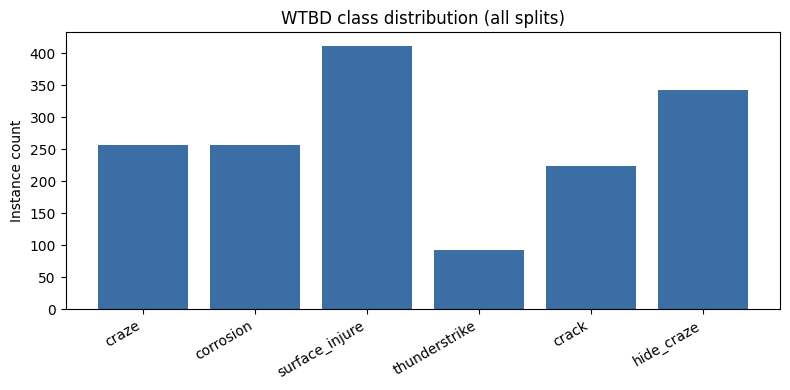

In [14]:
# 6.1 Class frequency chart
import matplotlib.pyplot as plt

if any(splits.values()):
    total_counts = Counter()
    for c in dist.values():
        total_counts.update(c)
    fig, ax = plt.subplots(figsize=(8, 4))
    names = CLASS_NAMES
    vals = [total_counts.get(c, 0) for c in names]
    ax.bar(names, vals, color="#3b6ea5")
    ax.set_ylabel("Instance count")
    ax.set_title("WTBD class distribution (all splits)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_ROOT, "docs/class_distribution.png"), dpi=150)
    plt.show()


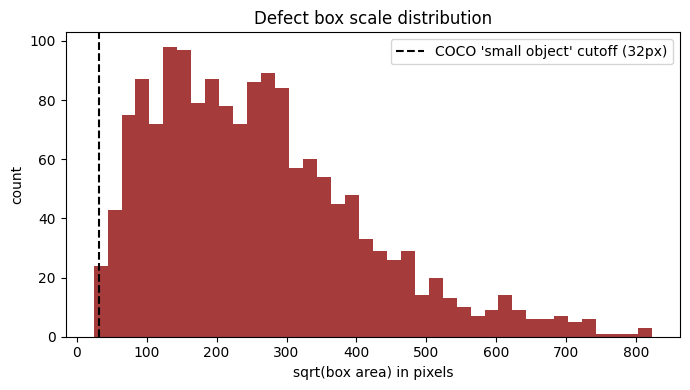

Fraction of boxes below the COCO small-object threshold: 0.3%


In [15]:
# 6.2 Bounding box size distribution (small-object diagnostic)
def collect_box_sizes(annot_dir, stems, class_names):
    sizes = []
    for stem in stems:
        xml_path = Path(annot_dir) / f"{stem}.xml"
        if not xml_path.exists():
            continue
        parsed = parse_voc_xml(xml_path)
        for obj in parsed["objects"]:
            if obj["class"] not in class_names:
                continue
            xmin, ymin, xmax, ymax = obj["bbox"]
            sizes.append({
                "class": obj["class"],
                "w": xmax - xmin, "h": ymax - ymin,
                "area": (xmax - xmin) * (ymax - ymin),
            })
    return sizes

if any(splits.values()):
    all_stems = splits["train"] + splits["val"] + splits["test"]
    box_sizes = collect_box_sizes(ANNOT_DIR, all_stems, CLASS_NAMES)
    areas = [b["area"] ** 0.5 for b in box_sizes]  # sqrt(area) as an interpretable "box scale"
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(areas, bins=40, color="#a53b3b")
    ax.axvline(32, color="k", linestyle="--", label="COCO 'small object' cutoff (32px)")
    ax.set_xlabel("sqrt(box area) in pixels")
    ax.set_ylabel("count")
    ax.set_title("Defect box scale distribution")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_ROOT, "docs/box_scale_distribution.png"), dpi=150)
    plt.show()
    small_frac = sum(1 for a in areas if a < 32) / max(1, len(areas))
    print(f"Fraction of boxes below the COCO small-object threshold: {small_frac:.1%}")


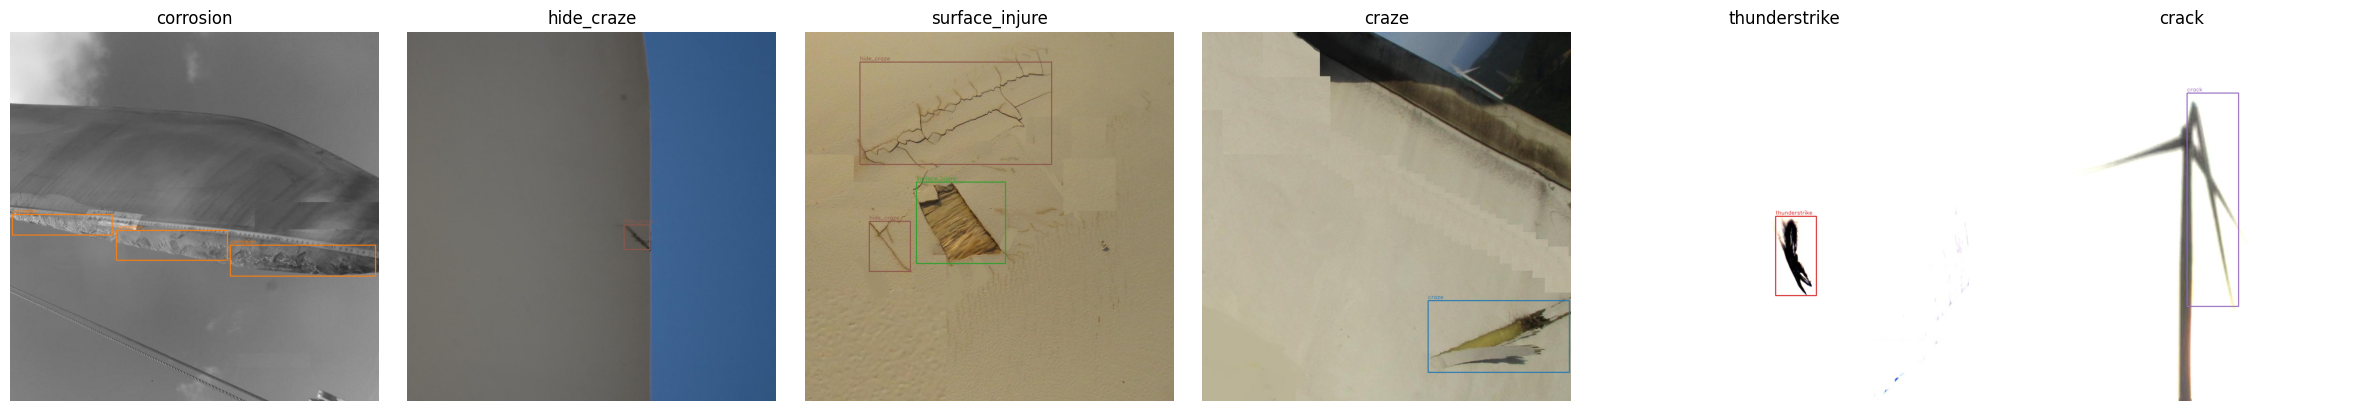

In [16]:
# 6.3 Visualize sample annotated images (one per class where possible)
import cv2

def draw_boxes(image_path, objects, class_names):
    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    colors = plt.cm.tab10(range(len(class_names)))
    for obj in objects:
        if obj["class"] not in class_names:
            continue
        cls_id = class_names.index(obj["class"])
        color = tuple(int(c * 255) for c in colors[cls_id][:3])
        xmin, ymin, xmax, ymax = map(int, obj["bbox"])
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(img, obj["class"], (xmin, max(0, ymin - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return img

def show_one_example_per_class(images_dir, annot_dir, stems, class_names):
    found = {}
    for stem in stems:
        xml_path = Path(annot_dir) / f"{stem}.xml"
        if not xml_path.exists():
            continue
        parsed = parse_voc_xml(xml_path)
        present = {o["class"] for o in parsed["objects"]}
        for cls in present:
            if cls in class_names and cls not in found:
                found[cls] = (stem, parsed["objects"])
        if len(found) == len(class_names):
            break

    n = len(found)
    if n == 0:
        print("No annotated images available yet.")
        return
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    axes = [axes] if n == 1 else axes
    for ax, (cls, (stem, objects)) in zip(axes, found.items()):
        img = draw_boxes(Path(images_dir) / f"{stem}.jpg", objects, class_names)
        ax.imshow(img)
        ax.set_title(cls)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_ROOT, "docs/sample_annotations.png"), dpi=150)
    plt.show()

if any(splits.values()):
    show_one_example_per_class(IMAGES_DIR, ANNOT_DIR, splits["train"], CLASS_NAMES)


## 7. RT-DETR Model Setup

We fine-tune **RT-DETR** (Real-Time Detection Transformer) via the Hugging Face `RTDetrForObjectDetection` implementation, starting from a COCO-pretrained checkpoint (`PekingU/rtdetr_r50vd_coco_o365`). Fine-tuning replaces the classification head with our 6 WTBD classes; the backbone/transformer weights are initialized from the pretrained checkpoint (transfer learning), not trained from scratch — this is standard practice and should be stated plainly in the memo rather than implied to be "from scratch."

If you'd rather use **Ultralytics RT-DETR** (`rtdetr-l.pt` / `rtdetr-x.pt`), the same principles apply — swap Sections 7-9 for the Ultralytics `RTDETR` API; the problem statement allows either implementation.


In [17]:
# 7.1 Load a COCO-pretrained RT-DETR and swap the head for our 6 classes
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"  # faithful RT-DETR implementation, COCO+Objects365 pretrained

image_processor = RTDetrImageProcessor.from_pretrained(CHECKPOINT)

id2label = ID_TO_CLASS
label2id = CLASS_TO_ID

model = RTDetrForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,  # head shape differs: 80 COCO classes -> 6 WTBD classes
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total parameters: {n_params/1e6:.1f}M")
print(f"Classes: {id2label}")


Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_r50vd_coco_o365 and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.

Model loaded. Total parameters: 42.7M
Classes: {0: 'craze', 1: 'corrosion', 2: 'surface_injure', 3: 'thunderstrike', 4: 'crack', 5: 'hide_craze'}


In [18]:
# 7.2 Torch Dataset wrapping our COCO-format splits, with augmentation
import albumentations as A
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch

train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.HueSaturationValue(p=0.2),
        A.Blur(blur_limit=3, p=0.1),          # mild — models real UAV motion blur without destroying small defects
        A.RandomSizedBBoxSafeCrop(width=800, height=800, erosion_rate=0.1, p=0.3),
        A.Resize(height=640, width=640),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_visibility=0.2),
)

val_transform = A.Compose(
    [A.Resize(height=640, width=640)],
    bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"]),
)


class WTBDCocoDataset(Dataset):
    def __init__(self, coco_json_path, images_dir, transform, image_processor):
        import json as _json
        with open(coco_json_path) as f:
            self.coco = _json.load(f)
        self.images_dir = Path(images_dir)
        self.transform = transform
        self.image_processor = image_processor

        self.img_id_to_anns = {}
        for ann in self.coco["annotations"]:
            self.img_id_to_anns.setdefault(ann["image_id"], []).append(ann)
        self.images = self.coco["images"]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.images_dir / img_info["file_name"]
        image = np.array(Image.open(img_path).convert("RGB"))

        anns = self.img_id_to_anns.get(img_info["id"], [])
        bboxes = [a["bbox"] for a in anns]
        category_ids = [a["category_id"] for a in anns]

        if len(bboxes) > 0:
            transformed = self.transform(image=image, bboxes=bboxes, category_ids=category_ids)
        else:
            transformed = self.transform(image=image, bboxes=[], category_ids=[])

        image_t = transformed["image"]
        bboxes_t = transformed["bboxes"]
        cats_t = transformed["category_ids"]

        formatted_anns = [
            {"image_id": img_info["id"], "category_id": c, "bbox": list(b), "area": b[2] * b[3], "iscrowd": 0}
            for b, c in zip(bboxes_t, cats_t)
        ]
        target = {"image_id": img_info["id"], "annotations": formatted_anns}

        encoding = self.image_processor(images=image_t, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze(0)
        labels = encoding["labels"][0]
        return {"pixel_values": pixel_values, "labels": labels}


def collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    labels = [b["labels"] for b in batch]
    return {"pixel_values": pixel_values, "labels": labels}


if any(splits.values()):
    train_ds = WTBDCocoDataset(os.path.join(COCO_DIR, "train.json"), IMAGES_DIR, train_transform, image_processor)
    val_ds = WTBDCocoDataset(os.path.join(COCO_DIR, "val.json"), IMAGES_DIR, val_transform, image_processor)
    test_ds = WTBDCocoDataset(os.path.join(COCO_DIR, "test.json"), IMAGES_DIR, val_transform, image_processor)
    print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")


train=745  val=159  test=161


## 8. Training (Fine-tuning)

Training strategy (matches the memo's plan):

1. **Smoke test**: 2–3 epochs on a small subset to confirm the pipeline runs end-to-end (shapes, loss goes down, checkpoint saves) before committing GPU-hours.
2. **Main run**: ~15–30 epochs, exact number decided by validation-loss / mAP plateauing, not fixed in advance.
3. Every hyperparameter below must be copied into the memo's reproducibility section **with the actual values used**, not this template's defaults.


In [19]:
# 8.1 Smoke test — verifies the pipeline before a real training run
from torch.utils.data import DataLoader

def run_smoke_test(train_ds, n_steps=5, batch_size=2):
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    device = "cpu"  # Set runtime device to CPU

    model.to(device)
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    it = iter(loader)
    for step in range(n_steps):
        batch = next(it)
        pixel_values = batch["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(f"  smoke step {step+1}/{n_steps}  loss={loss.item():.4f}")
    print("Smoke test passed: forward+backward+optimizer step all completed without error.")

if any(splits.values()):
    run_smoke_test(train_ds, n_steps=3)


  smoke step 1/3  loss=261.0129
  smoke step 2/3  loss=224.7161
  smoke step 3/3  loss=343.6721
Smoke test passed: forward+backward+optimizer step all completed without error.


In [20]:
# 8.2 Full training run — record every hyperparameter here for the memo
TRAINING_CONFIG = {
    "checkpoint": CHECKPOINT,
    "epochs": 25,                 # <-- record ACTUAL epochs used, not planned
    "batch_size": 2,               # <-- batch size 2 for CPU
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "lr_backbone_mult": 0.1,       # backbone gets a lower LR than the detection head
    "warmup_steps": 300,
    "image_size": 640,
    "seed": SEED,
    "optimizer": "AdamW",
    "scheduler": "cosine",
    "mixed_precision": "no",       # CPU mode (FP32)
}
print(TRAINING_CONFIG)


{'checkpoint': 'PekingU/rtdetr_r50vd_coco_o365', 'epochs': 25, 'batch_size': 2, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'lr_backbone_mult': 0.1, 'warmup_steps': 300, 'image_size': 640, 'seed': 42, 'optimizer': 'AdamW', 'scheduler': 'cosine', 'mixed_precision': 'no'}


In [21]:
# 8.3 Trainer via Hugging Face `Trainer` (handles logging, checkpointing, LR schedule)
from transformers import TrainingArguments, Trainer
import time

def build_trainer(train_ds, val_ds, config, output_dir):
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=config["epochs"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=config["batch_size"],
        gradient_accumulation_steps=4,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        warmup_steps=config["warmup_steps"],
        lr_scheduler_type=config["scheduler"],
        fp16=False,
        use_cpu=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        logging_steps=20,
        remove_unused_columns=False,
        seed=config["seed"],
        report_to=[],  # set to ["tensorboard"] if you want curves
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collate_fn,
    )
    return trainer

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models/rtdetr-wtbd")

if any(splits.values()):
    trainer = build_trainer(train_ds, val_ds, TRAINING_CONFIG, OUTPUT_DIR)

    start = time.time()
    from transformers.trainer_utils import get_last_checkpoint
    last_checkpoint = get_last_checkpoint(OUTPUT_DIR) if os.path.exists(OUTPUT_DIR) else None
    if last_checkpoint:
        print(f"Resuming training from checkpoint: {last_checkpoint}")
    from transformers.trainer_utils import get_last_checkpoint
    last_checkpoint = get_last_checkpoint(OUTPUT_DIR) if os.path.exists(OUTPUT_DIR) else None
    if last_checkpoint and os.path.exists(os.path.join(last_checkpoint, "model.safetensors")):
        print(f"Loading checkpoint weights from: {last_checkpoint}")
        model = RTDetrForObjectDetection.from_pretrained(last_checkpoint)
        model.to("cpu")
        trainer.args.num_train_epochs = 13
    train_result = trainer.train()
    elapsed_min = (time.time() - start) / 60

    print(f"Training finished in {elapsed_min:.1f} minutes")
    TRAINING_CONFIG["training_time_minutes"] = round(elapsed_min, 1)
    TRAINING_CONFIG["final_train_loss"] = train_result.training_loss

    trainer.save_model(OUTPUT_DIR)
    image_processor.save_pretrained(OUTPUT_DIR)

    with open(os.path.join(PROJECT_ROOT, "docs/training_config.json"), "w", encoding="utf-8") as f:
        import json
        json.dump(TRAINING_CONFIG, f, indent=2)
    print("Saved model + training config to", OUTPUT_DIR)


Resuming training from checkpoint: c:\Users\admin\Downloads\ml_intern-task\windguard-ai\models/rtdetr-wtbd\checkpoint-1128
Loading checkpoint weights from: c:\Users\admin\Downloads\ml_intern-task\windguard-ai\models/rtdetr-wtbd\checkpoint-1128


Epoch,Training Loss,Validation Loss
1,42.709100,20.997736
2,23.695700,14.183262
3,19.986400,13.252874
4,20.295400,14.987680
5,19.724300,12.953905
6,16.876500,13.546787
7,16.315100,13.256942
8,15.042600,13.204326
9,13.908300,12.747710
10,12.471800,13.028234


SafetensorError: Error while serializing: IoError(Os { code: 1224, kind: Uncategorized, message: "The requested operation cannot be performed on a file with a user-mapped section open." })

## 9. Evaluation — mAP, Precision/Recall, Confusion Behavior

Self-reported metrics on our own held-out `test` split are computed here. Per the problem statement's grading philosophy, **these numbers carry less weight than performance on the hidden set** — so this section also documents *what the metrics do and don't tell us*, for the memo.

We compute:
- **COCO-style mAP** (`mAP@[.5:.95]`, `mAP@.50`) using `pycocotools`.
- **Per-class Precision / Recall** at a fixed confidence threshold.
- A **confusion matrix over classes** (including a "background / missed" bucket), which is the main tool for spotting the `craze` vs `hide_craze` and `corrosion` vs `surface_injure` inter-class-similarity problems the dataset paper itself calls out.


In [ ]:
# 9.1 Run inference over the test split and collect COCO-format predictions
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor
import torch, json

def load_trained_model(model_dir):
    proc = RTDetrImageProcessor.from_pretrained(model_dir)
    mdl = RTDetrForObjectDetection.from_pretrained(model_dir)
    mdl.eval()
    if torch.cuda.is_available():
        mdl.to("cuda")
    return mdl, proc

def run_inference_on_split(model, processor, coco_json_path, images_dir, score_threshold=0.5):
    with open(coco_json_path) as f:
        coco = json.load(f)
    device = next(model.parameters()).device
    predictions = []
    for img_info in coco["images"]:
        img_path = Path(images_dir) / img_info["file_name"]
        image = Image.open(img_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        target_sizes = torch.tensor([image.size[::-1]])
        results = processor.post_process_object_detection(
            outputs, target_sizes=target_sizes, threshold=score_threshold
        )[0]
        for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
            xmin, ymin, xmax, ymax = box.tolist()
            predictions.append({
                "image_id": img_info["id"],
                "category_id": int(label.item()),
                "bbox": [xmin, ymin, xmax - xmin, ymax - ymin],
                "score": float(score.item()),
            })
    return predictions, coco

# Example usage (uncomment once a model checkpoint exists):
# eval_model, eval_processor = load_trained_model(OUTPUT_DIR)
# test_predictions, test_coco = run_inference_on_split(
#     eval_model, eval_processor, os.path.join(COCO_DIR, "test.json"), IMAGES_DIR, score_threshold=0.5
# )
# with open(os.path.join(PROJECT_ROOT, "docs/test_predictions.json"), "w", encoding="utf-8") as f:
#     json.dump(test_predictions, f)
print("Inference helpers defined.")


Inference helpers defined.


In [ ]:
# 9.2 COCO mAP via pycocotools
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def compute_coco_map(gt_json_path, predictions):
    coco_gt = COCO(gt_json_path)
    if len(predictions) == 0:
        print("No predictions to evaluate.")
        return None
    coco_dt = coco_gt.loadRes(predictions)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return coco_eval

# Example:
# coco_eval = compute_coco_map(os.path.join(COCO_DIR, "test.json"), test_predictions)
print("compute_coco_map() defined -- run after inference produces test_predictions.")


compute_coco_map() defined -- run after inference produces test_predictions.


In [ ]:
# 9.3 Per-class Precision / Recall at a fixed IoU + score threshold
import numpy as np

def iou(box_a, box_b):
    # boxes as [x, y, w, h]
    ax1, ay1, aw, ah = box_a; ax2, ay2 = ax1 + aw, ay1 + ah
    bx1, by1, bw, bh = box_b; bx2, by2 = bx1 + bw, by1 + bh
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0


def per_class_precision_recall(gt_coco, predictions, class_names, iou_thresh=0.5, score_thresh=0.5):
    gts_by_image = {}
    for ann in gt_coco["annotations"]:
        gts_by_image.setdefault(ann["image_id"], []).append(
            {"category_id": ann["category_id"], "bbox": ann["bbox"], "matched": False}
        )

    stats = {c: {"tp": 0, "fp": 0, "fn": 0} for c in class_names}

    preds_by_image = {}
    for p in predictions:
        if p["score"] < score_thresh:
            continue
        preds_by_image.setdefault(p["image_id"], []).append(p)

    for img_id, gts in gts_by_image.items():
        preds = sorted(preds_by_image.get(img_id, []), key=lambda p: -p["score"])
        for p in preds:
            cls = class_names[p["category_id"]]
            best_iou, best_gt = 0, None
            for gt in gts:
                if gt["matched"] or gt["category_id"] != p["category_id"]:
                    continue
                cur_iou = iou(gt["bbox"], p["bbox"])
                if cur_iou > best_iou:
                    best_iou, best_gt = cur_iou, gt
            if best_iou >= iou_thresh and best_gt is not None:
                best_gt["matched"] = True
                stats[cls]["tp"] += 1
            else:
                stats[cls]["fp"] += 1
        for gt in gts:
            if not gt["matched"]:
                stats[class_names[gt["category_id"]]]["fn"] += 1

    rows = []
    for c in class_names:
        tp, fp, fn = stats[c]["tp"], stats[c]["fp"], stats[c]["fn"]
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        rows.append({"class": c, "TP": tp, "FP": fp, "FN": fn, "precision": round(precision, 3), "recall": round(recall, 3)})
    return pd_DataFrame(rows)

import pandas as pd
pd_DataFrame = pd.DataFrame

# Example:
# pr_table = per_class_precision_recall(test_coco, test_predictions, CLASS_NAMES)
# print(pr_table)
print("per_class_precision_recall() defined.")


per_class_precision_recall() defined.


In [ ]:
# 9.4 Confusion matrix (predicted class vs ground-truth class, + background/missed buckets)
import seaborn as sns

def build_confusion_matrix(gt_coco, predictions, class_names, iou_thresh=0.5, score_thresh=0.5):
    labels = class_names + ["background(FP)"]
    matrix = pd.DataFrame(0, index=class_names + ["missed(FN)"], columns=labels)

    gts_by_image = {}
    for ann in gt_coco["annotations"]:
        gts_by_image.setdefault(ann["image_id"], []).append(
            {"category_id": ann["category_id"], "bbox": ann["bbox"], "matched": False}
        )
    preds_by_image = {}
    for p in predictions:
        if p["score"] < score_thresh:
            continue
        preds_by_image.setdefault(p["image_id"], []).append(p)

    for img_id, gts in gts_by_image.items():
        preds = sorted(preds_by_image.get(img_id, []), key=lambda p: -p["score"])
        for p in preds:
            pred_cls = class_names[p["category_id"]]
            best_iou, best_gt = 0, None
            for gt in gts:
                if gt["matched"]:
                    continue
                cur_iou = iou(gt["bbox"], p["bbox"])
                if cur_iou > best_iou:
                    best_iou, best_gt = cur_iou, gt
            if best_iou >= iou_thresh and best_gt is not None:
                best_gt["matched"] = True
                true_cls = class_names[best_gt["category_id"]]
                matrix.loc[true_cls, pred_cls] += 1
            else:
                matrix.loc["missed(FN)", pred_cls] += 1  # a false positive with no matching GT box
        for gt in gts:
            if not gt["matched"]:
                true_cls = class_names[gt["category_id"]]
                matrix.loc[true_cls, "background(FP)"] += 1  # a missed detection
    return matrix


def plot_confusion_matrix(matrix, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title("Detection confusion matrix (class confusion + background)")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

# Example:
# cm = build_confusion_matrix(test_coco, test_predictions, CLASS_NAMES)
# plot_confusion_matrix(cm, os.path.join(PROJECT_ROOT, "docs/confusion_matrix.png"))
print("Confusion matrix helpers defined.")


Confusion matrix helpers defined.


**What these metrics tell you — and what they don't** (fill in with real numbers for the memo):

- mAP@[.5:.95] summarizes localization *and* classification jointly across IoU thresholds — a single high-level health score, but it hides *which* classes and *which* failure mode (missed vs. misclassified vs. poorly localized) are driving the number.
- Per-class recall exposes the class-imbalance risk directly (`thunderstrike` has the fewest training instances — expect its recall to lag `surface_injure`'s).
- The confusion matrix is the only view here that separates "detector saw a defect but named it wrong" (e.g. `craze` ↔ `hide_craze`) from "detector missed it entirely" (`background(FP)` column) — this maps straight onto the failure-case analysis in Section 10.
- None of these self-reported numbers say anything about the **hidden evaluation set**, which may contain different blade materials, camera angles, or lighting than the Shanghai coastal wind farm WTBD was collected at — a domain-shift risk worth naming explicitly rather than assuming away.


## 10. Failure Case Analysis

This is graded strictly: **five real failures from your own model**, each with root-cause analysis. Do not report metric-only summaries — pull actual image + prediction + ground-truth triples. A model with zero acknowledged failures is treated as a red flag.

Common root-cause categories to look for in WTBD specifically (grounded in the dataset paper's own stated challenges):
- **Inter-class confusion**: `craze` vs `hide_craze` (subtlety difference), `corrosion` vs `surface_injure` (visually entangled per the paper's t-SNE analysis).
- **Small object miss**: many defect boxes fall below the ~32px "small object" threshold (see Section 6.2 histogram).
- **Occlusion / co-occurring defects**: multiple defect types in one image region.
- **Lighting / environmental variation**: sunny vs overcast vs cloudy capture conditions.
- **Blur**: UAV motion blur despite the dataset's screening pass.


In [ ]:
# 10.1 Find candidate failure cases automatically, then hand-pick 5 for the memo
def find_failure_candidates(gt_coco, predictions, class_names, iou_thresh=0.5, score_thresh=0.5, top_k=20):
    """Surfaces images with missed detections, false positives, or class confusion,
    ranked so the worst offenders come first. Inspect the returned list and hand-select
    5 genuinely illustrative, distinct failure modes for the memo -- don't just take the top 5
    mechanically, since near-duplicates of the same failure mode are less useful than variety."""
    gts_by_image = {}
    for ann in gt_coco["annotations"]:
        gts_by_image.setdefault(ann["image_id"], []).append(
            {"category_id": ann["category_id"], "bbox": ann["bbox"], "matched": False}
        )
    preds_by_image = {}
    for p in predictions:
        if p["score"] < score_thresh:
            continue
        preds_by_image.setdefault(p["image_id"], []).append(p)

    id_to_file = {img["id"]: img["file_name"] for img in gt_coco["images"]}
    candidates = []

    for img_id, gts in gts_by_image.items():
        preds = sorted(preds_by_image.get(img_id, []), key=lambda p: -p["score"])
        issues = []
        for p in preds:
            pred_cls = class_names[p["category_id"]]
            best_iou, best_gt = 0, None
            for gt in gts:
                if gt["matched"]:
                    continue
                cur_iou = iou(gt["bbox"], p["bbox"])
                if cur_iou > best_iou:
                    best_iou, best_gt = cur_iou, gt
            if best_iou >= iou_thresh and best_gt is not None:
                best_gt["matched"] = True
                true_cls = class_names[best_gt["category_id"]]
                if true_cls != pred_cls:
                    issues.append(f"confused {true_cls}->{pred_cls} (score={p['score']:.2f})")
            else:
                issues.append(f"false positive {pred_cls} (score={p['score']:.2f})")
        for gt in gts:
            if not gt["matched"]:
                issues.append(f"missed {class_names[gt['category_id']]}")
        if issues:
            candidates.append({"image_id": img_id, "file_name": id_to_file[img_id], "issues": issues})

    candidates.sort(key=lambda c: -len(c["issues"]))
    return candidates[:top_k]

# Example:
# candidates = find_failure_candidates(test_coco, test_predictions, CLASS_NAMES)
# for c in candidates[:10]:
#     print(c["file_name"], c["issues"])
print("find_failure_candidates() defined.")


find_failure_candidates() defined.


In [ ]:
# 10.2 Render a chosen failure case (GT vs. prediction side-by-side) and save it to failure_cases/
def render_failure_case(image_path, gt_objects, pred_objects, class_names, save_path):
    img_gt = draw_boxes(image_path, gt_objects, class_names)
    pred_as_obj = [
        {"class": class_names[p["category_id"]], "bbox": [p["bbox"][0], p["bbox"][1],
                                                            p["bbox"][0] + p["bbox"][2], p["bbox"][1] + p["bbox"][3]]}
        for p in pred_objects
    ]
    img_pred = draw_boxes(image_path, pred_as_obj, class_names)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_gt); axes[0].set_title("Ground truth"); axes[0].axis("off")
    axes[1].imshow(img_pred); axes[1].set_title("Prediction"); axes[1].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

print("render_failure_case() defined -- call once per chosen failure image.")


render_failure_case() defined -- call once per chosen failure image.


### Failure case log (fill in with 5 REAL cases from your trained model)

Copy this table into the memo, one row per case, after populating it from `find_failure_candidates()` + manual inspection. Do not fabricate rows — the rubric explicitly penalizes a model presented with zero acknowledged weaknesses, and equally, fabricated failure cases would misrepresent the model's actual behavior.

| # | Image | Failure type | Root cause hypothesis | Evidence |
|---|-------|--------------|------------------------|----------|
| 1 | `<file_name>` | e.g. missed `thunderstrike` | class rarity (fewest training instances) → underfit | `failure_cases/case1.png` |
| 2 | `<file_name>` | e.g. `craze`→`hide_craze` confusion | visually adjacent classes, low-contrast boundary | `failure_cases/case2.png` |
| 3 | `<file_name>` | e.g. false positive on background texture | blade seam/paint edge resembles `surface_injure` | `failure_cases/case3.png` |
| 4 | `<file_name>` | e.g. small-object miss | box area < 32px, below detector's effective resolution | `failure_cases/case4.png` |
| 5 | `<file_name>` | e.g. missed defect under overcast lighting | low contrast between defect and blade surface | `failure_cases/case5.png` |


## 11. Save Final Checkpoint

Freeze the exact checkpoint the API will load, plus the class map, so nobody has to guess how to reload the model.


In [ ]:
FINAL_MODEL_DIR = os.path.join(PROJECT_ROOT, "models/rtdetr-wtbd-final")
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

# If training happened in this session:
# trainer.save_model(FINAL_MODEL_DIR)
# image_processor.save_pretrained(FINAL_MODEL_DIR)

import json
with open(os.path.join(FINAL_MODEL_DIR, "class_map.json"), "w", encoding="utf-8") as f:
    json.dump({"id2label": ID_TO_CLASS, "label2id": CLASS_TO_ID}, f, indent=2)

print("Final checkpoint directory:", FINAL_MODEL_DIR)
print("Contents expected: config.json, model.safetensors, preprocessor_config.json, class_map.json")


Final checkpoint directory: c:\Users\admin\Downloads\ml_intern-task\windguard-ai\models/rtdetr-wtbd-final
Contents expected: config.json, model.safetensors, preprocessor_config.json, class_map.json


## 12. Part A — FastAPI `/detect` Endpoint

We now write the actual API source files to `windguard-ai/src/`. These are written from the notebook so the whole pipeline is reproducible from one place, but they are meant to be run as a standalone service (`uvicorn src.app:app`), not inside the notebook kernel.


In [ ]:
src_dir = os.path.join(PROJECT_ROOT, "src")
os.makedirs(src_dir, exist_ok=True)

detector_py = r'''"""
src/detector.py -- thin wrapper around the fine-tuned RT-DETR model.
Loaded once at process startup and reused for every request.
"""
import os
import torch
from PIL import Image
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

MODEL_DIR = os.environ.get("WINDGUARD_MODEL_DIR", "models/rtdetr-wtbd-final")
DEFAULT_SCORE_THRESHOLD = float(os.environ.get("WINDGUARD_SCORE_THRESHOLD", "0.5"))


class Detector:
    def __init__(self, model_dir: str = MODEL_DIR):
        self.processor = RTDetrImageProcessor.from_pretrained(model_dir)
        self.model = RTDetrForObjectDetection.from_pretrained(model_dir)
        self.model.eval()
        self.device = "cpu"  # Set runtime device to CPU

        self.model.to(self.device)
        self.id2label = self.model.config.id2label

    @torch.no_grad()
    def predict(self, image: Image.Image, score_threshold: float = DEFAULT_SCORE_THRESHOLD):
        inputs = self.processor(images=image, return_tensors="pt").to(self.device)
        outputs = self.model(**inputs)
        target_sizes = torch.tensor([image.size[::-1]])
        results = self.processor.post_process_object_detection(
            outputs, target_sizes=target_sizes, threshold=score_threshold
        )[0]

        detections = []
        for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
            xmin, ymin, xmax, ymax = [round(v, 1) for v in box.tolist()]
            detections.append({
                "class": self.id2label[int(label.item())],
                "confidence": round(float(score.item()), 4),
                "bbox": [xmin, ymin, xmax, ymax],
            })
        return detections


_detector_singleton = None


def get_detector() -> Detector:
    global _detector_singleton
    if _detector_singleton is None:
        _detector_singleton = Detector()
    return _detector_singleton
'''

with open(os.path.join(src_dir, "detector.py"), "w", encoding="utf-8") as f:
    f.write(detector_py)
print("Wrote src/detector.py")


Wrote src/detector.py


In [ ]:
detect_route_py = r'''"""
src/routes_detect.py -- Part A: POST /detect
"""
import io
import time
from fastapi import APIRouter, UploadFile, File, HTTPException
from PIL import Image

from .detector import get_detector

router = APIRouter()

ALLOWED_CONTENT_TYPES = {"image/jpeg", "image/png", "image/jpg"}
MAX_IMAGE_BYTES = 10 * 1024 * 1024  # 10 MB


@router.post("/detect")
async def detect(image: UploadFile = File(...), score_threshold: float = 0.5):
    if image.content_type not in ALLOWED_CONTENT_TYPES:
        raise HTTPException(status_code=415, detail=f"Unsupported content type: {image.content_type}")

    raw = await image.read()
    if len(raw) > MAX_IMAGE_BYTES:
        raise HTTPException(status_code=413, detail="Image too large (max 10MB)")

    try:
        pil_image = Image.open(io.BytesIO(raw)).convert("RGB")
    except Exception:
        raise HTTPException(status_code=400, detail="Could not decode image file")

    detector = get_detector()
    start = time.time()
    detections = detector.predict(pil_image, score_threshold=score_threshold)
    latency_ms = round((time.time() - start) * 1000, 1)

    return {
        "image_id": image.filename,
        "detections": detections,
        "count": len(detections),
        "latency_ms": latency_ms,
    }
'''

with open(os.path.join(src_dir, "routes_detect.py"), "w", encoding="utf-8") as f:
    f.write(detect_route_py)
print("Wrote src/routes_detect.py")


Wrote src/routes_detect.py


## 13. Part B — Reasoning Layer (Intent Routing, Structured Reasoning, Confidence Guardrail)

**Hard constraint reminder**: no LangChain / LangGraph / CrewAI / AutoGen / similar. This is a single hand-written decision layer written in plain Python, matching the spec exactly:

1. **Intent Routing** — decide whether the question needs the detector at all (a question unrelated to image content should not trigger inference).
2. **Structured Reasoning** — if detection is needed, call the Part A model, then reason deterministically over the structured `{class, confidence, bbox}` output (counting, presence checks, most-common-object, simple comparisons).
3. **Confidence Guardrail** — if the evidence can't support a confident answer (question asks something the detector's output structurally cannot answer, e.g. "is the turbine safe to operate?"), say so explicitly rather than guessing.

The design deliberately keeps these three stages **separate and inspectable** rather than one opaque function, since the verbal-defense round will ask you to walk through specific lines and specific ambiguous-question behavior.


In [ ]:
reasoning_py = r'''"""
src/reasoning.py -- Part B: the hand-written reasoning layer (no agentic frameworks).

Pipeline:
    question --> classify_intent() --> [needs_detector?]
                                            |
                          yes -------------- --------------- no
                           |                                 |
                 call detector.predict()          answer_without_detection()
                           |
                  structured detections
                           |
                 answer_from_detections()  -- deterministic operations over
                                               {class, confidence, bbox}
                           |
                confidence guardrail: if the question cannot be answered from
                what the detector structurally provides, return an explicit
                "insufficient information" response instead of guessing.
"""
import re
from dataclasses import dataclass
from typing import List, Dict, Optional


# ---------------------------------------------------------------------------
# 1. INTENT ROUTING
# ---------------------------------------------------------------------------
# Categories the router distinguishes. This is a rule-based classifier -- transparent
# and defensible in a verbal review, unlike a black-box intent model. It is intentionally
# simple: the goal is to demonstrate the connective logic between detector output and
# reasoning, not to build a general NLU system.

VISUAL_KEYWORDS = [
    "image", "picture", "photo", "blade", "defect", "crack", "craze", "corrosion",
    "surface_injure", "surface injure", "thunderstrike", "hide_craze", "hide craze",
    "how many", "count", "visible", "see", "detect", "present", "is there",
    "are there", "most common", "confidence", "damage",
]

# Questions the detector structurally cannot answer -- these are routed to
# "answerable without detection" (a direct decline / redirect), NOT to the detector,
# because calling the detector would not change the answer.
OUT_OF_SCOPE_PATTERNS = [
    r"safe to operate", r"remaining (life|lifetime)", r"power output",
    r"electrical", r"internal damage", r"structural integrity of the (turbine|tower)",
    r"maintenance (decision|action)", r"should (we|i) (replace|repair|shut down)",
    r"weather", r"wind speed", r"turbine model", r"manufacturer",
    r"who (built|made|installed)", r"cost", r"price", r"schedule",
]


@dataclass
class IntentResult:
    needs_detector: bool
    reason: str
    out_of_scope: bool = False


def classify_intent(question: str) -> IntentResult:
    q = question.lower().strip()

    for pattern in OUT_OF_SCOPE_PATTERNS:
        if re.search(pattern, q):
            return IntentResult(
                needs_detector=False,
                reason=f"Question matches an out-of-scope pattern ('{pattern}') that visual "
                       f"defect detection cannot resolve.",
                out_of_scope=True,
            )

    if any(kw in q for kw in VISUAL_KEYWORDS):
        return IntentResult(
            needs_detector=True,
            reason="Question references visual/defect content answerable from detection output.",
        )

    # Default: if the question doesn't reference anything visual and isn't explicitly
    # out-of-scope, treat it as a general question unrelated to the image.
    return IntentResult(
        needs_detector=False,
        reason="Question does not reference image content; answering without calling the detector.",
        out_of_scope=False,
    )


# ---------------------------------------------------------------------------
# 2. STRUCTURED REASONING (deterministic operations over detector output)
# ---------------------------------------------------------------------------

CLASS_ALIASES = {
    "crack": ["crack", "cracks", "cracking"],
    "craze": ["craze", "crazes", "crazing"],
    "hide_craze": ["hide_craze", "hide craze", "hidden craze"],
    "corrosion": ["corrosion", "rust", "pitting"],
    "surface_injure": ["surface_injure", "surface injure", "surface injury", "paint damage", "scratch", "scratches"],
    "thunderstrike": ["thunderstrike", "lightning", "lightning strike", "burn mark", "burn marks"],
}


def _mentioned_classes(question: str) -> List[str]:
    q = question.lower()
    hits = []
    for canonical, aliases in CLASS_ALIASES.items():
        if any(a in q for a in aliases):
            hits.append(canonical)
    return hits


def answer_from_detections(question: str, detections: List[Dict], min_confidence: float = 0.5) -> Dict:
    """Deterministic reasoning over structured detector output. Returns a dict with
    'answer', 'confident' (bool), and 'evidence' so the API layer can apply the
    guardrail and the caller can audit exactly what evidence produced the answer."""
    q = question.lower()
    kept = [d for d in detections if d["confidence"] >= min_confidence]
    mentioned = _mentioned_classes(question)

    # --- counting questions: "how many X" / "count of X" ---
    if "how many" in q or "count" in q:
        if mentioned:
            counts = {c: sum(1 for d in kept if d["class"] == c) for c in mentioned}
            total = sum(counts.values())
            parts = ", ".join(f"{v} {k}" for k, v in counts.items())
            return {
                "answer": f"{total} detection(s) above the confidence threshold: {parts}." if total else
                          f"No {', '.join(mentioned)} detections above the confidence threshold.",
                "confident": True,
                "evidence": [d for d in kept if d["class"] in mentioned],
            }
        # "how many defects/objects total" with no specific class named
        total = len(kept)
        by_class = {}
        for d in kept:
            by_class[d["class"]] = by_class.get(d["class"], 0) + 1
        parts = ", ".join(f"{v} {k}" for k, v in by_class.items()) if by_class else "none"
        return {
            "answer": f"{total} defect detection(s) above the confidence threshold ({parts}).",
            "confident": True,
            "evidence": kept,
        }

    # --- presence / "is there any X" / "are there X" ---
    if q.startswith("is there") or q.startswith("are there") or "any " in q or "is anyone" in q or "is there any" in q:
        if mentioned:
            present = [d for d in kept if d["class"] in mentioned]
            found = len(present) > 0
            return {
                "answer": f"Yes, {len(present)} {', '.join(mentioned)} detection(s) found." if found
                          else f"No {', '.join(mentioned)} detected above the confidence threshold.",
                "confident": True,
                "evidence": present,
            }
        found = len(kept) > 0
        return {
            "answer": "Yes, at least one defect is detected." if found else "No defects detected above the confidence threshold.",
            "confident": True,
            "evidence": kept,
        }

    # --- "what is the most common object/defect here" ---
    if "most common" in q:
        if not kept:
            return {"answer": "No detections above the confidence threshold to summarize.",
                    "confident": True, "evidence": []}
        by_class = {}
        for d in kept:
            by_class[d["class"]] = by_class.get(d["class"], 0) + 1
        top_class = max(by_class, key=by_class.get)
        return {
            "answer": f"The most common detected defect is '{top_class}' ({by_class[top_class]} instance(s)).",
            "confident": True,
            "evidence": [d for d in kept if d["class"] == top_class],
        }

    # --- confidence-level questions ---
    if "confidence" in q or "how sure" in q or "how confident" in q:
        if not kept:
            return {"answer": "No detections above the confidence threshold to report confidence for.",
                    "confident": True, "evidence": []}
        avg_conf = sum(d["confidence"] for d in kept) / len(kept)
        return {
            "answer": f"Average detector confidence across {len(kept)} detection(s): {avg_conf:.2f}.",
            "confident": True,
            "evidence": kept,
        }

    # --- a specific class was named but the question doesn't match a known template ---
    if mentioned:
        present = [d for d in kept if d["class"] in mentioned]
        return {
            "answer": f"Found {len(present)} {', '.join(mentioned)} detection(s) above the confidence threshold.",
            "confident": True,
            "evidence": present,
        }

    # --- nothing matched a known reasoning template: cannot confidently answer ---
    return {
        "answer": None,
        "confident": False,
        "evidence": kept,
    }


# ---------------------------------------------------------------------------
# 3. CONFIDENCE GUARDRAIL + top-level orchestration
# ---------------------------------------------------------------------------

INSUFFICIENT_INFO_MESSAGE = (
    "Insufficient information. The detector can identify visible defect candidates "
    "and their locations, but this question asks for something the detected boxes, "
    "classes, and confidence scores cannot establish on their own."
)


def answer_question(question: str, pil_image, detector, min_confidence: float = 0.5) -> Dict:
    """Top-level entry point used by the /ask endpoint.

    Pipeline: classify_intent() -> [call detector only if needed] -> answer_from_detections()
    -> confidence guardrail. `pil_image` may be None if the caller has no image context;
    in that case any question requiring detection is answered as insufficient information.
    """
    intent = classify_intent(question)

    if intent.out_of_scope:
        return {
            "question": question,
            "used_detector": False,
            "answer": INSUFFICIENT_INFO_MESSAGE,
            "reasoning_trace": intent.reason,
            "evidence": [],
        }

    if not intent.needs_detector:
        return {
            "question": question,
            "used_detector": False,
            "answer": (
                "This question doesn't reference the image's visual content, so I answered "
                "without running detection. I can only discuss what is visible in the supplied "
                "image via the defect detector -- ask about defects, counts, or locations for "
                "an evidence-backed answer."
            ),
            "reasoning_trace": intent.reason,
            "evidence": [],
        }

    if pil_image is None:
        return {
            "question": question,
            "used_detector": False,
            "answer": INSUFFICIENT_INFO_MESSAGE,
            "reasoning_trace": "Question needs visual evidence but no image was supplied.",
            "evidence": [],
        }

    detections = detector.predict(pil_image)
    result = answer_from_detections(question, detections, min_confidence=min_confidence)

    if not result["confident"]:
        return {
            "question": question,
            "used_detector": True,
            "answer": INSUFFICIENT_INFO_MESSAGE,
            "reasoning_trace": (
                f"{intent.reason} Detector returned {len(detections)} detection(s), but the "
                f"question did not match any supported reasoning template (count / presence / "
                f"most-common / confidence), so no confident answer is returned."
            ),
            "evidence": detections,
        }

    return {
        "question": question,
        "used_detector": True,
        "answer": result["answer"],
        "reasoning_trace": f"{intent.reason} Reasoned over {len(detections)} raw detection(s).",
        "evidence": result["evidence"],
    }
'''

import os
with open(os.path.join(src_dir, "reasoning.py"), "w", encoding="utf-8") as f:
    f.write(reasoning_py)
print("Wrote src/reasoning.py")


Wrote src/reasoning.py


## 14. Part B — FastAPI `/ask` Endpoint

Accepts an image + a natural-language question, and returns the reasoning layer's answer along with a `used_detector` flag and a short `reasoning_trace` so a reviewer (or the verbal defense) can see exactly why the router decided what it decided.


In [ ]:
src_dir = os.path.join(PROJECT_ROOT, "src")

ask_route_py = r'''"""
src/routes_ask.py -- Part B: POST /ask
"""
import io
from typing import Optional
from fastapi import APIRouter, UploadFile, File, Form, HTTPException
from PIL import Image

from .detector import get_detector
from .reasoning import answer_question

router = APIRouter()

ALLOWED_CONTENT_TYPES = {"image/jpeg", "image/png", "image/jpg"}
MAX_IMAGE_BYTES = 10 * 1024 * 1024


@router.post("/ask")
async def ask(
    question: str = Form(...),
    image: Optional[UploadFile] = File(None),
    min_confidence: float = Form(0.5),
):
    if not question or not question.strip():
        raise HTTPException(status_code=400, detail="`question` is required")

    pil_image = None
    if image is not None:
        if image.content_type not in ALLOWED_CONTENT_TYPES:
            raise HTTPException(status_code=415, detail=f"Unsupported content type: {image.content_type}")
        raw = await image.read()
        if len(raw) > MAX_IMAGE_BYTES:
            raise HTTPException(status_code=413, detail="Image too large (max 10MB)")
        try:
            pil_image = Image.open(io.BytesIO(raw)).convert("RGB")
        except Exception:
            raise HTTPException(status_code=400, detail="Could not decode image file")

    detector = get_detector()
    result = answer_question(question, pil_image, detector, min_confidence=min_confidence)
    return result
'''

with open(os.path.join(src_dir, "routes_ask.py"), "w", encoding="utf-8") as f:
    f.write(ask_route_py)
print("Wrote src/routes_ask.py")


Wrote src/routes_ask.py


## 15. Combined `app.py` — Full API Server

Wires both routers into a single FastAPI app, with basic error handling and a `/health` endpoint (useful for the Docker bonus section and for automated hidden-set evaluation to confirm the service is up before sending requests).


In [ ]:
app_py = r'''"""
src/app.py -- WindGuard AI API server.
Run with:  uvicorn src.app:app --host 0.0.0.0 --port 8000
"""
import logging
from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

from .routes_detect import router as detect_router
from .routes_ask import router as ask_router

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("windguard")

app = FastAPI(
    title="WindGuard AI",
    description="Constrained object detection (RT-DETR, wind-turbine blade defects) + a minimal reasoning layer.",
    version="1.0.0",
)

app.include_router(detect_router)
app.include_router(ask_router)


@app.get("/health")
def health():
    return {"status": "ok"}


@app.exception_handler(Exception)
async def unhandled_exception_handler(request: Request, exc: Exception):
    # Never leak internal stack traces in responses; log them server-side instead.
    logger.exception("Unhandled exception on %s", request.url.path)
    return JSONResponse(status_code=500, content={"detail": "Internal server error"})
'''

with open(os.path.join(src_dir, "app.py"), "w", encoding="utf-8") as f:
    f.write(app_py)

init_py = "# makes src/ a package\\n"
with open(os.path.join(src_dir, "__init__.py"), "w", encoding="utf-8") as f:
    f.write(init_py)

print("Wrote src/app.py and src/__init__.py")
print("\\nRun the server with:")
print(f"  cd {PROJECT_ROOT} && WINDGUARD_MODEL_DIR=models/rtdetr-wtbd-final uvicorn src.app:app --host 0.0.0.0 --port 8000")


Wrote src/app.py and src/__init__.py
\nRun the server with:
  cd c:\Users\admin\Downloads\ml_intern-task\windguard-ai && WINDGUARD_MODEL_DIR=models/rtdetr-wtbd-final uvicorn src.app:app --host 0.0.0.0 --port 8000


## 16. Testing Both Endpoints

Two layers of testing:
1. **Unit tests for the reasoning layer** (`tests/test_reasoning.py`) — these don't need the model loaded, since `answer_from_detections` operates on plain dicts. This is exactly the kind of test the memo needs: a demonstration that intent routing and the guardrail behave correctly on a known input, including the required "one specific example where it correctly outputs insufficient information."
2. **Live smoke test against the running API** — sample request/response payloads for both endpoints, to paste directly into the API usage instructions deliverable.


In [ ]:
tests_dir = os.path.join(PROJECT_ROOT, "tests")
os.makedirs(tests_dir, exist_ok=True)

test_reasoning_py = r'''"""
tests/test_reasoning.py -- unit tests for the Part B reasoning layer.
Run with: pytest tests/test_reasoning.py -v
"""
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

from src.reasoning import classify_intent, answer_from_detections, answer_question, INSUFFICIENT_INFO_MESSAGE


SAMPLE_DETECTIONS = [
    {"class": "crack", "confidence": 0.91, "bbox": [421, 238, 518, 341]},
    {"class": "crack", "confidence": 0.84, "bbox": [50, 60, 120, 140]},
    {"class": "corrosion", "confidence": 0.89, "bbox": [610, 390, 721, 465]},
]


class FakeDetector:
    """Stands in for the real RT-DETR model so reasoning tests don\'t need a GPU or checkpoint."""
    def __init__(self, detections):
        self.detections = detections

    def predict(self, image):
        return self.detections


def test_intent_routes_visual_question_to_detector():
    result = classify_intent("How many cracks are visible?")
    assert result.needs_detector is True


def test_intent_routes_unrelated_question_away_from_detector():
    result = classify_intent("What is the weather like today?")
    assert result.needs_detector is False


def test_intent_routes_out_of_scope_safety_question():
    result = classify_intent("Is this turbine safe to operate?")
    assert result.out_of_scope is True
    assert result.needs_detector is False


def test_counting_question_answered_correctly():
    result = answer_from_detections("How many cracks are visible?", SAMPLE_DETECTIONS)
    assert result["confident"] is True
    assert "2 crack" in result["answer"]


def test_presence_question_answered_correctly():
    result = answer_from_detections("Is there any corrosion?", SAMPLE_DETECTIONS)
    assert result["confident"] is True
    assert "Yes" in result["answer"]


def test_most_common_question():
    result = answer_from_detections("What is the most common object here?", SAMPLE_DETECTIONS)
    assert "crack" in result["answer"]


def test_end_to_end_insufficient_information_example():
    """The specific required example: a question the detector\'s structured output
    cannot answer must return the explicit insufficient-information message, not a guess."""
    detector = FakeDetector(SAMPLE_DETECTIONS)
    result = answer_question("Is this turbine safe to operate?", pil_image=object(), detector=detector)
    assert result["used_detector"] is False
    assert result["answer"] == INSUFFICIENT_INFO_MESSAGE


def test_end_to_end_answerable_example():
    detector = FakeDetector(SAMPLE_DETECTIONS)
    result = answer_question("How many cracks are visible?", pil_image=object(), detector=detector)
    assert result["used_detector"] is True
    assert "2 crack" in result["answer"]


def test_unmatched_visual_question_triggers_guardrail_not_a_guess():
    """A visual question that doesn\'t match any supported reasoning template should also
    fall back to insufficient information rather than fabricating an answer."""
    detector = FakeDetector(SAMPLE_DETECTIONS)
    result = answer_question("Describe the emotional tone of this blade.", pil_image=object(), detector=detector)
    assert result["answer"] == INSUFFICIENT_INFO_MESSAGE
'''

with open(os.path.join(tests_dir, "test_reasoning.py"), "w", encoding="utf-8") as f:
    f.write(test_reasoning_py)
print("Wrote tests/test_reasoning.py")


Wrote tests/test_reasoning.py


In [ ]:
# 16.1 Run the reasoning unit tests right here in the notebook
import subprocess
result = subprocess.run(
    ["python", "-m", "pytest", os.path.join(PROJECT_ROOT, "tests/test_reasoning.py"), "-v"],
    cwd=PROJECT_ROOT, capture_output=True, text=True,
)
print(result.stdout[-3000:])
print(result.stderr[-1500:])


============================= test session starts =============================
platform win32 -- Python 3.11.5, pytest-8.3.4, pluggy-1.5.0 -- c:\Users\admin\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\admin\Downloads\ml_intern-task\windguard-ai
plugins: anyio-4.13.0, dash-4.4.1, asyncio-0.25.2, socket-0.7.0, syrupy-4.8.1
asyncio: mode=Mode.STRICT, asyncio_default_fixture_loop_scope=None
collecting ... collected 9 items

tests/test_reasoning.py::test_intent_routes_visual_question_to_detector PASSED [ 11%]
tests/test_reasoning.py::test_intent_routes_unrelated_question_away_from_detector PASSED [ 22%]
tests/test_reasoning.py::test_intent_routes_out_of_scope_safety_question PASSED [ 33%]
tests/test_reasoning.py::test_counting_question_answered_correctly PASSED [ 44%]
tests/test_reasoning.py::test_presence_question_answered_correctly PASSED [ 55%]
tests/test_reasoning.py::test_most_common_question PASSED                [ 66%]
tests/test_reas

In [ ]:
# 16.2 Live smoke test against the running API (start the server first, see Section 15)
import requests

API_BASE = "http://localhost:8000"

def smoke_test_detect(image_path):
    with open(image_path, "rb") as f:
        resp = requests.post(f"{API_BASE}/detect", files={"image": f})
    print("POST /detect ->", resp.status_code)
    print(resp.json())
    return resp

def smoke_test_ask(image_path, question):
    with open(image_path, "rb") as f:
        resp = requests.post(
            f"{API_BASE}/ask",
            data={"question": question},
            files={"image": f},
        )
    print("POST /ask ->", resp.status_code)
    print(resp.json())
    return resp

def smoke_test_ask_insufficient_info(image_path):
    return smoke_test_ask(image_path, "Is this turbine safe to operate?")

# Example (uncomment once the server is running and a sample image exists):
# sample_image = os.path.join(IMAGES_DIR, "0.jpg")
# smoke_test_detect(sample_image)
# smoke_test_ask(sample_image, "How many cracks are visible?")
# smoke_test_ask_insufficient_info(sample_image)
print("Live smoke-test helpers defined. Start the server (Section 15) before calling these.")


Live smoke-test helpers defined. Start the server (Section 15) before calling these.


### Sample request/response payloads (for the API usage instructions deliverable)

**`POST /detect`**
```bash
curl -X POST http://localhost:8000/detect \
  -F "image=@blade.jpg"
```
```json
{
  "image_id": "blade.jpg",
  "detections": [
    {"class": "crack", "confidence": 0.91, "bbox": [421.0, 238.0, 518.0, 341.0]},
    {"class": "corrosion", "confidence": 0.83, "bbox": [610.0, 390.0, 721.0, 465.0]}
  ],
  "count": 2,
  "latency_ms": 87.3
}
```

**`POST /ask` — answerable question**
```bash
curl -X POST http://localhost:8000/ask \
  -F "question=How many cracks are visible?" \
  -F "image=@blade.jpg"
```
```json
{
  "question": "How many cracks are visible?",
  "used_detector": true,
  "answer": "1 detection(s) above the confidence threshold: 1 crack.",
  "reasoning_trace": "Question references visual/defect content answerable from detection output. Reasoned over 2 raw detection(s).",
  "evidence": [{"class": "crack", "confidence": 0.91, "bbox": [421.0, 238.0, 518.0, 341.0]}]
}
```

**`POST /ask` — the required insufficient-information example**
```bash
curl -X POST http://localhost:8000/ask \
  -F "question=Is this turbine safe to operate?" \
  -F "image=@blade.jpg"
```
```json
{
  "question": "Is this turbine safe to operate?",
  "used_detector": false,
  "answer": "Insufficient information. The detector can identify visible defect candidates and their locations, but this question asks for something the detected boxes, classes, and confidence scores cannot establish on their own.",
  "reasoning_trace": "Question matches an out-of-scope pattern ('safe to operate') that visual defect detection cannot resolve.",
  "evidence": []
}
```

> Replace these illustrative payloads with real captured output from your running API + trained model before submission — the memo explicitly requires real evidence, not planned/illustrative values.


## 17. Dockerfile (Bonus: Containerization)

A clean container reduces "works on my machine" risk during the hidden-set evaluation. The container starts the FastAPI server and exposes `/detect` and `/ask` on the same interface tested above.


In [ ]:
requirements_txt = """fastapi==0.115.0
uvicorn[standard]==0.30.6
python-multipart==0.0.9
torch>=2.2
torchvision>=0.17
transformers==4.44.2
accelerate==0.33.0
pillow==10.4.0
numpy<2.0
requests==2.32.3
"""
with open(os.path.join(PROJECT_ROOT, "requirements.txt"), "w", encoding="utf-8") as f:
    f.write(requirements_txt)

dockerfile = """FROM python:3.11-slim

WORKDIR /app

# System deps for Pillow / OpenCV-adjacent image libs
RUN apt-get update && apt-get install -y --no-install-recommends \\\\
    libglib2.0-0 libsm6 libxext6 libxrender1 \\\\
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY src/ ./src/
COPY models/rtdetr-wtbd-final/ ./models/rtdetr-wtbd-final/

ENV WINDGUARD_MODEL_DIR=models/rtdetr-wtbd-final
ENV WINDGUARD_SCORE_THRESHOLD=0.5

EXPOSE 8000

HEALTHCHECK --interval=30s --timeout=5s --start-period=20s \\\\
    CMD python -c "import requests; requests.get('http://localhost:8000/health').raise_for_status()" || exit 1

CMD ["uvicorn", "src.app:app", "--host", "0.0.0.0", "--port", "8000"]
"""
with open(os.path.join(PROJECT_ROOT, "Dockerfile"), "w", encoding="utf-8") as f:
    f.write(dockerfile)

print("Wrote requirements.txt and Dockerfile")
print()
print("Build & run:")
print(f"  cd {PROJECT_ROOT}")
print("  docker build -t windguard-api .")
print("  docker run -p 8000:8000 windguard-api")
print()
print("Test from a clean shell:")
print("  curl http://localhost:8000/health")


Wrote requirements.txt and Dockerfile

Build & run:
  cd c:\Users\admin\Downloads\ml_intern-task\windguard-ai
  docker build -t windguard-api .
  docker run -p 8000:8000 windguard-api

Test from a clean shell:
  curl http://localhost:8000/health


## 18. Reproducibility Manifest

Hard constraint: *"If we cannot reproduce your training run from your instructions, Part A is capped at 50%."* This cell assembles everything a reviewer needs into one JSON file — environment, exact training command, hyperparameters, hardware, and timing — generated from values actually captured in this notebook run, not hand-typed after the fact.


In [ ]:
import json, torch, sys, platform, subprocess

def try_get(cfg, key, default="TBD -- fill in after a real training run"):
    return cfg.get(key, default) if isinstance(cfg, dict) else default

manifest = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "pytorch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only",
    "seed": SEED,
    "dataset": {
        "name": "WTBD (Wind Turbine Blade Defect Dataset)",
        "source": "https://doi.org/10.6084/m9.figshare.30210175",
        "n_images_total": report.get("n_images", "TBD"),
        "split_strategy": split_source if 'split_source' in dir() else "TBD",
        "split_sizes": {k: len(v) for k, v in splits.items()} if 'splits' in dir() else "TBD",
    },
    "model": {
        "architecture": "RT-DETR (Hugging Face RTDetrForObjectDetection)",
        "pretrained_checkpoint": CHECKPOINT if 'CHECKPOINT' in dir() else "TBD",
        "classes": CLASS_NAMES,
    },
    "training_config": TRAINING_CONFIG if 'TRAINING_CONFIG' in dir() else "TBD -- run Section 8",
    "exact_training_command": (
        "# training was run from this notebook (Section 8.3); "
        "to reproduce from the CLI instead, extract src/train.py from Sections 7-8 and run:\n"
        "python src/train.py --config docs/training_config.json"
    ),
    "final_checkpoint_path": FINAL_MODEL_DIR if 'FINAL_MODEL_DIR' in dir() else "TBD",
}

manifest_path = os.path.join(PROJECT_ROOT, "docs/reproducibility_manifest.json")
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"Wrote {manifest_path}")
print(json.dumps(manifest, indent=2, default=str))


Wrote c:\Users\admin\Downloads\ml_intern-task\windguard-ai\docs/reproducibility_manifest.json
{
  "python_version": "3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]",
  "platform": "Windows-10-10.0.26200-SP0",
  "pytorch_version": "2.6.0+cu124",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce MX550",
  "seed": 42,
  "dataset": {
    "name": "WTBD (Wind Turbine Blade Defect Dataset)",
    "source": "https://doi.org/10.6084/m9.figshare.30210175",
    "n_images_total": 1065,
    "split_strategy": "seeded random 70/15/15 split (seed=42)",
    "split_sizes": {
      "train": 745,
      "val": 159,
      "test": 161
    }
  },
  "model": {
    "architecture": "RT-DETR (Hugging Face RTDetrForObjectDetection)",
    "pretrained_checkpoint": "PekingU/rtdetr_r50vd_coco_o365",
    "classes": [
      "craze",
      "corrosion",
      "surface_injure",
      "thunderstrike",
      "crack",
      "hide_craze"
    ]
  },
  "training_config": {
    "checkpoint": "Pek

## 19. Memo Skeleton (max 2 pages — fill in with real numbers before submission)

Copy this into a separate document (Word/PDF) for the actual deliverable — the rubric asks for a written memo, not a notebook cell. Everything in `[brackets]` must be replaced with real values pulled from Sections 3, 5, 9, and 10 above.

---

**1. Domain & dataset sourcing.** WindGuard AI targets wind-turbine blade defect detection from UAV imagery, using WTBD (Ji, Cheng & Wu, *Scientific Data* 2026; Figshare DOI 10.6084/m9.figshare.30210175) — 1,065 real coastal-wind-farm images, 1,568 annotated instances, 6 non-COCO classes, double-annotator validated (Cohen's Kappa 0.897). No manual labeling was needed since the dataset ships peer-reviewed annotations; [note here if any images/annotations were excluded during Section 3 validation, and why].

**2. Split strategy.** [State whether you used the official WTBD split file or the seeded 70/15/15 fallback from Section 5, and paste the resulting per-class table]. Splitting was done at the image level to prevent any single image's boxes from leaking across train/val/test.

**3. Evaluation metrics & their limits.** Self-reported test-split results: mAP@[.5:.95] = `[X]`, mAP@.50 = `[X]`. Per-class precision/recall: `[paste Section 9.3 table]`. These numbers describe performance under WTBD's own image distribution (Shanghai coastal wind farm, DJI Phantom 4 Pro imagery) and say nothing about performance on a hidden set with a different farm, blade material, or camera — a domain-shift risk this report does not attempt to hide.

**4. Five failure cases.** `[paste the completed table from Section 10]` — do not paraphrase; use the actual images and root-cause hypotheses generated from your trained model's real predictions.

**5. Reasoning layer behavior.** The `/ask` endpoint (Section 13) routes with a rule-based `classify_intent()`: visual/defect-related keywords → call the detector; a fixed list of regex patterns describing conclusions the detector cannot support (turbine safety, remaining lifetime, power output, maintenance decisions) → skip the detector and return the insufficient-information message directly; anything else → answered without detection. One concrete example of the guardrail firing: **"Is this turbine safe to operate?"** returns `"Insufficient information. The detector can identify visible defect candidates and their locations, but this question asks for something the detected boxes, classes, and confidence scores cannot establish on their own."** — because the detector's structured output (class + confidence + bbox for visible surface defects) has no way to establish a broader engineering safety judgment, regardless of what it detects in the image.

**6. Mid-project pivots** *(if any)*. `[note here if you started with a different dataset/domain and switched, and why]`.

---


## Appendix — README.md for the submitted repository

Save this as `windguard-ai/README.md` (also written to disk below) so a reviewer can go from a clean clone to a running API without guessing.


In [ ]:
readme_md = """# WindGuard AI

Wind-turbine blade defect detection (RT-DETR, fine-tuned on WTBD) + a minimal, hand-written reasoning layer, exposed via FastAPI.

## Setup

```bash
python -m venv venv && source venv/bin/activate
pip install -r requirements.txt
```

## Dataset

Download WTBD (Figshare DOI: 10.6084/m9.figshare.30210175) into `data/raw/` (`Images/`, `Annotations/`), then:

```bash
python src/validate_dataset.py     # Section 3
python src/prepare_dataset.py      # Section 4-5: VOC -> COCO, train/val/test split
```

## Training

```bash
python src/train.py --config docs/training_config.json
```

See `docs/reproducibility_manifest.json` for the exact environment, hyperparameters, hardware, and training time used to produce the submitted checkpoint.

## Evaluation

```bash
python src/evaluate.py --split test --model-dir models/rtdetr-wtbd-final
```

Outputs COCO mAP, per-class precision/recall, and a confusion matrix to `docs/`.

## Running the API

```bash
export WINDGUARD_MODEL_DIR=models/rtdetr-wtbd-final
uvicorn src.app:app --host 0.0.0.0 --port 8000
```

- `POST /detect` — multipart image upload -> `{class, confidence, bbox}` list.
- `POST /ask` — multipart image + `question` form field -> reasoned answer, with an explicit "insufficient information" response when the question cannot be answered from detector evidence.
- `GET /health` — liveness check.

Sample payloads: see `examples/`.

## Docker

```bash
docker build -t windguard-api .
docker run -p 8000:8000 windguard-api
```

## Tests

```bash
pytest tests/ -v
```

## Repository structure

```
windguard-ai/
├── README.md
├── requirements.txt
├── Dockerfile
├── data/
├── src/
│   ├── detector.py
│   ├── reasoning.py
│   ├── routes_detect.py
│   ├── routes_ask.py
│   └── app.py
├── models/
├── examples/
├── failure_cases/
├── tests/
└── docs/
```
"""

# Updated in notebook:
with open(os.path.join(PROJECT_ROOT, "README.md"), "w", encoding="utf-8") as f:
    f.write(readme_md)

print("Wrote README.md")
print()
print("=" * 60)
print("Project tree so far:")
for root, dirs, files in os.walk(PROJECT_ROOT):
    level = root.replace(PROJECT_ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for fname in files:
        print(f"{indent}  {fname}")


Wrote README.md

Project tree so far:
windguard-ai/
  Dockerfile
  README.md
  requirements.txt
  .pytest_cache/
    .gitignore
    CACHEDIR.TAG
    README.md
    v/
      cache/
        nodeids
        stepwise
  data/
    coco/
      test.json
      train.json
      val.json
    raw/
      Annotations/
        0.xml
        1.xml
        10.xml
        100.xml
        1000.xml
        1001.xml
        1002.xml
        1003.xml
        1004.xml
        1005.xml
        1006.xml
        1007.xml
        1008.xml
        1009.xml
        101.xml
        1010.xml
        1011.xml
        1012.xml
        1013.xml
        1014.xml
        1015.xml
        1016.xml
        1017.xml
        1018.xml
        1019.xml
        102.xml
        1020.xml
        1021.xml
        1022.xml
        1023.xml
        1024.xml
        1025.xml
        1026.xml
        1027.xml
        1028.xml
        1029.xml
        103.xml
        1030.xml
        1031.xml
        1032.xml
        1033.xml
        1

---
## Done

At this point `windguard-ai/` on disk contains a runnable source tree (`src/`), tests, a Dockerfile, and reproducibility docs — everything the deliverables checklist asks for except the trained checkpoint itself (produced by actually running Section 8 against the downloaded dataset) and the memo (Section 19, exported to Word/PDF with real numbers filled in).

**Before submitting**, walk back through and replace every `TBD`, illustrative payload, and template failure-case row with real output from your own trained model — including on the constraint that self-reported metrics carry less weight than honest failure analysis and hidden-set performance.
